# Telco Customer Churn Prediction

Customer churn costs telecoms an average of **$300 per lost customer** in acquisition costs alone. Predicting which customers are likely to leave — and understanding *why* — allows targeted retention interventions before it is too late.

This notebook walks through the full ML pipeline: data loading, exploratory analysis, preprocessing, training three classifiers, evaluating them, selecting the best by ROC-AUC, and generating SHAP explanations that translate model outputs into plain business language. It closes with an Amazon Bedrock comparator that benchmarks zero-shot LLM classification against the trained model, and an Azure App Service deployment case study.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import joblib
import json
from datetime import datetime
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

from shap_to_language import shap_values_to_factors

# Constants
MODEL_DIR    = Path('models')
PLOTS_DIR    = Path('plots')
RANDOM_STATE = 42
TEST_SIZE    = 0.2
DATA_URL     = (
    'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/'
    'master/data/Telco-Customer-Churn.csv'
)

MODEL_DIR.mkdir(exist_ok=True)
PLOTS_DIR.mkdir(exist_ok=True)

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
print('Imports complete.')

Imports complete.


## Dataset — IBM Telco Customer Churn

**7,043 customers · 21 features · ~26.5% churn rate**

The dataset was published by IBM as a sample dataset for their Cloud Pak for Data platform. Each row is one customer; the target column `Churn` records whether they left within the last month.

| Feature | Type | Business context |
|---|---|---|
| `tenure` | Numeric | Months as a customer. Strongly inversely correlated with churn. |
| `MonthlyCharges` | Numeric | Monthly bill amount. Higher charges are associated with higher churn. |
| `TotalCharges` | Numeric | Lifetime spend. Correlated with tenure. |
| `Contract` | Categorical | Month-to-month customers churn at ~43%; two-year customers at ~3%. |
| `InternetService` | Categorical | Fiber optic customers churn at ~42% vs DSL at ~19%. |
| `PaymentMethod` | Categorical | Electronic check users churn at ~45% — highest of any payment method. |
| `TechSupport` | Binary | Customers without tech support churn at twice the rate of those with it. |
| `OnlineSecurity` | Binary | Same pattern as tech support — a strong protective factor. |
| `SeniorCitizen` | Binary | Senior customers churn at ~42% vs ~24% for non-seniors. |
| `PaperlessBilling` | Binary | Correlated with electronic check; mildly positive churn signal. |

11 rows have a blank `TotalCharges` field (customers with zero tenure) — these are dropped.

In [2]:
print('Loading dataset…')
df = pd.read_csv(DATA_URL)
print(f'Shape: {df.shape}')

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
dropped = df['TotalCharges'].isna().sum()
df.dropna(subset=['TotalCharges'], inplace=True)
print(f'Dropped {dropped} rows with blank TotalCharges')

df['Churn'] = (df['Churn'] == 'Yes').astype(int)
df.drop(columns=['customerID'], inplace=True)

print(f'\nChurn rate: {df["Churn"].mean()*100:.1f}%')
print(f'Retained:   {(df["Churn"]==0).sum():,}')
print(f'Churned:    {(df["Churn"]==1).sum():,}')
df.head()

Loading dataset…
Shape: (7043, 21)
Dropped 11 rows with blank TotalCharges

Churn rate: 26.6%
Retained:   5,163
Churned:    1,869


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


## Exploratory Data Analysis

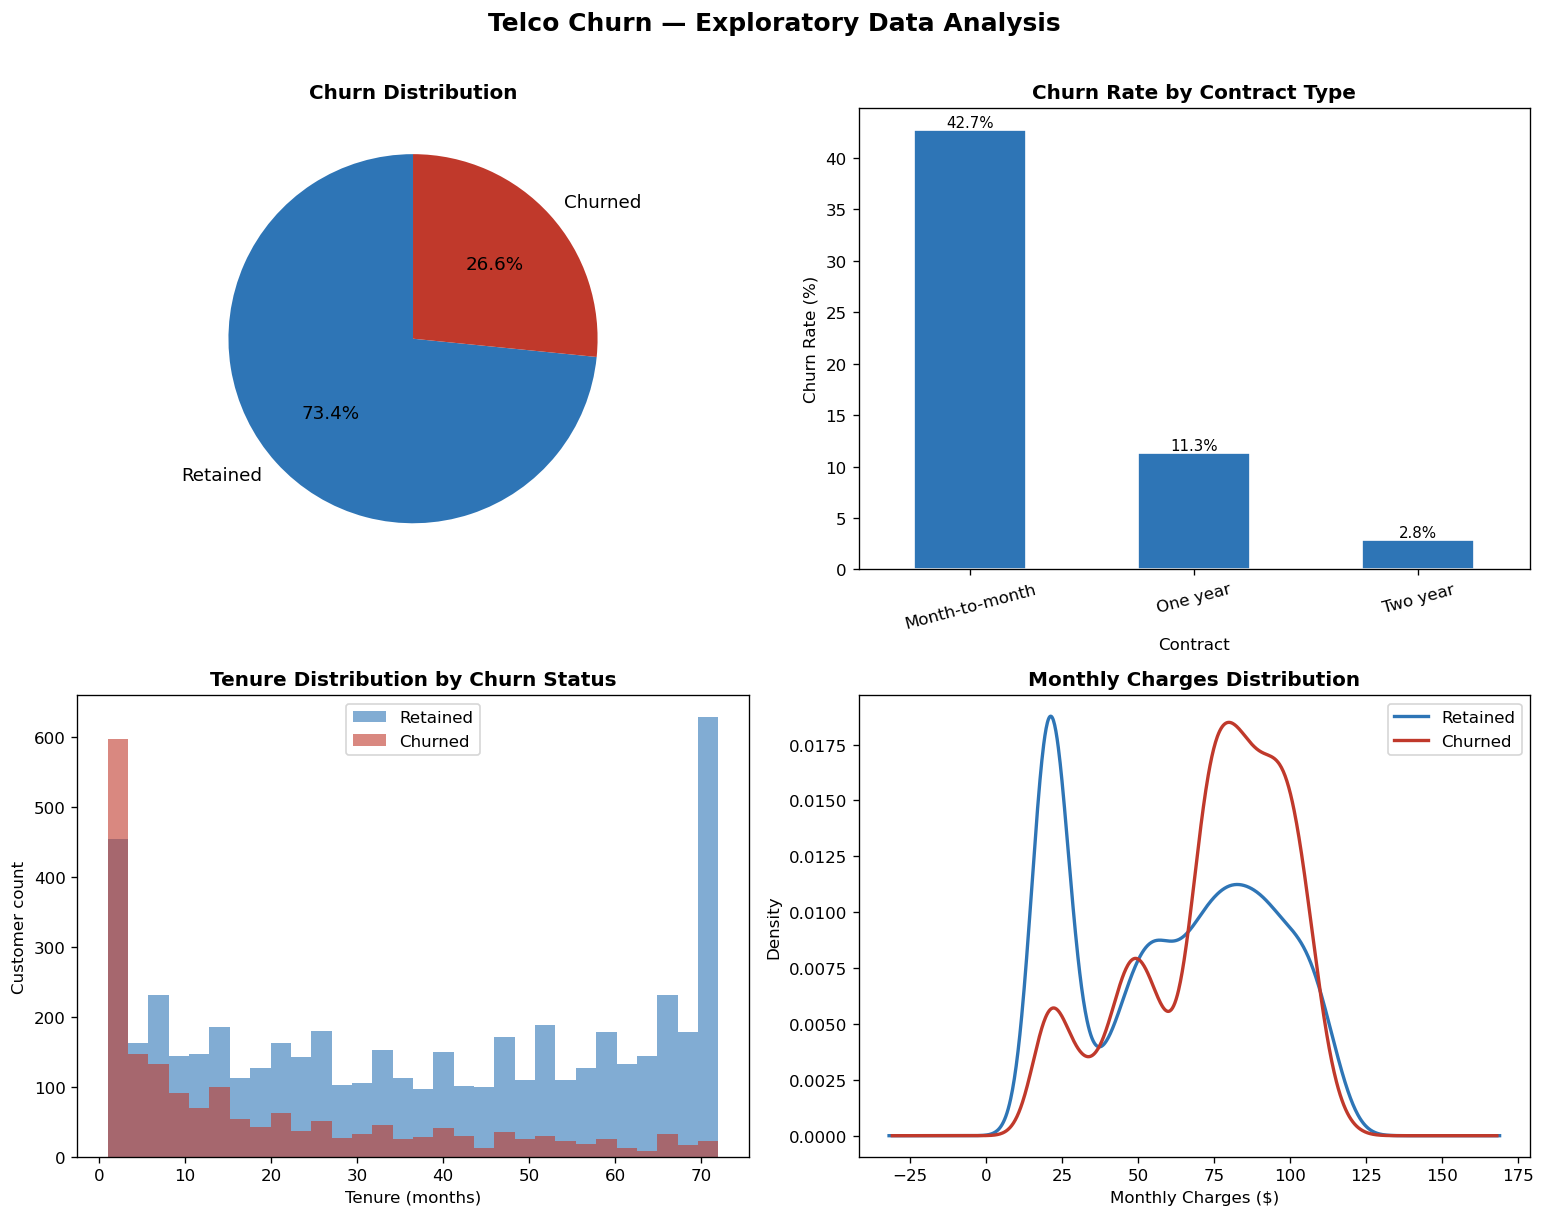

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle('Telco Churn — Exploratory Data Analysis', fontsize=15, fontweight='bold', y=1.01)

# 01 — Churn distribution
ax = axes[0, 0]
counts = df['Churn'].value_counts()
ax.pie(counts, labels=['Retained', 'Churned'], colors=['#2E75B6', '#C0392B'],
       autopct='%1.1f%%', startangle=90, textprops={'fontsize': 11})
ax.set_title('Churn Distribution', fontweight='bold')

# 02 — Churn rate by contract
ax = axes[0, 1]
contract_churn = df.groupby('Contract')['Churn'].mean() * 100
contract_churn.sort_values(ascending=False).plot(kind='bar', ax=ax,
    color='#2E75B6', edgecolor='white')
ax.set_title('Churn Rate by Contract Type', fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=15)
for bar in ax.patches:
    ax.annotate(f'{bar.get_height():.1f}%',
                (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom', fontsize=9)

# 03 — Tenure histogram by churn
ax = axes[1, 0]
ax.hist(df[df['Churn']==0]['tenure'], bins=30, alpha=0.6, color='#2E75B6', label='Retained')
ax.hist(df[df['Churn']==1]['tenure'], bins=30, alpha=0.6, color='#C0392B', label='Churned')
ax.set_title('Tenure Distribution by Churn Status', fontweight='bold')
ax.set_xlabel('Tenure (months)')
ax.set_ylabel('Customer count')
ax.legend()

# 04 — Monthly charges KDE
ax = axes[1, 1]
df[df['Churn']==0]['MonthlyCharges'].plot.kde(ax=ax, color='#2E75B6', label='Retained', linewidth=2)
df[df['Churn']==1]['MonthlyCharges'].plot.kde(ax=ax, color='#C0392B', label='Churned', linewidth=2)
ax.set_title('Monthly Charges Distribution', fontweight='bold')
ax.set_xlabel('Monthly Charges ($)')
ax.legend()

plt.tight_layout()
plt.savefig(PLOTS_DIR / '01_eda_combined.png', dpi=150, bbox_inches='tight')
plt.show()

## Preprocessing Decisions

**Why StandardScaler for numeric features?**  
Logistic Regression and distance-based algorithms are sensitive to feature magnitude — a tenure of 72 months and a monthly charge of $120 are on incompatible scales. StandardScaler centres each feature to zero mean and unit variance so no single feature dominates by magnitude. XGBoost is tree-based and invariant to monotonic transformations, but scaling is applied uniformly to keep the preprocessing pipeline identical across all three models.

**Why one-hot encoding for categoricals?**  
Features like `Contract` (Month-to-month / One year / Two year) have no natural numeric ordering — encoding them as 0/1/2 would imply Two year = 2 × One year, which is meaningless. One-hot encoding treats each category as a binary feature, making no ordinal assumption.

**Why `drop_first=True`?**  
With K categories, only K−1 binary columns are needed — the dropped category is fully implied when all others are zero. Keeping all K columns introduces perfect multicollinearity (the dummy variable trap), which inflates variance in Logistic Regression and adds redundant splits in tree models. Dropping the first category eliminates this without losing information.

**Why stratified split?**  
The dataset is imbalanced (~26.5% churn). A random split could place disproportionately few churned customers in the test set by chance, making evaluation metrics unreliable. Stratification guarantees that the churn ratio is preserved in both train and test sets, so evaluation reflects real-world class distribution.

In [4]:
df_proc = df.copy()

binary_cols = [
    'gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling',
    'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
]
for col in binary_cols:
    if col == 'gender':
        df_proc[col] = (df_proc[col] == 'Male').astype(int)
    else:
        df_proc[col] = (df_proc[col] == 'Yes').astype(int)

df_proc = pd.get_dummies(df_proc,
    columns=['Contract', 'PaymentMethod', 'InternetService'], drop_first=True)

y = df_proc.pop('Churn')
X = df_proc.copy()

numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

feature_names = list(X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print(f'Features:  {len(feature_names)}')
print(f'Train set: {len(X_train):,} rows')
print(f'Test set:  {len(X_test):,} rows')
print(f'\nFeature list:')
print(feature_names)

Features:  23
Train set: 5,625 rows
Test set:  1,407 rows

Feature list:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'InternetService_Fiber optic', 'InternetService_No']


## Model Selection

Three classifiers are trained to allow a meaningful comparison across the interpretability–performance spectrum:

**Logistic Regression** — the interpretable baseline. Coefficients map directly to log-odds, making predictions fully explainable without SHAP. It tends to underfit on non-linear datasets but provides a sanity check: if a complex model can't substantially beat logistic regression, the added complexity isn't justified.

**Random Forest** — a bagged ensemble of decision trees. It handles non-linear interactions between features without requiring feature scaling, and is robust to outliers. Its `feature_importances_` attribute gives a first approximation of feature relevance, though SHAP provides a more rigorous decomposition.

**XGBoost** — gradient-boosted trees, typically the strongest performer on structured/tabular data in industry benchmarks. Unlike bagging (Random Forest), boosting builds trees sequentially, each one correcting the residual errors of its predecessors. The `eval_metric='logloss'` setting optimises the log-loss objective, which is appropriate for binary probability calibration.

In [5]:
models = {
    'Logistic Regression': LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'XGBoost':             XGBClassifier(n_estimators=100, random_state=RANDOM_STATE,
                                         eval_metric='logloss', verbosity=0),
}

results = {}
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    results[name] = {
        'model':     model,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall':    recall_score(y_test, y_pred, zero_division=0),
        'F1':        f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC':   roc_auc_score(y_test, y_proba),
    }

comparison = pd.DataFrame(
    {name: {m: results[name][m] for m in metric_cols} for name in results}
).T

print('Model Comparison:')
print(comparison.to_string(float_format='{:.4f}'.format))

best_name  = max(results, key=lambda n: results[n]['ROC-AUC'])
best_model = results[best_name]['model']
print(f'\nBest model: {best_name} (ROC-AUC = {results[best_name]["ROC-AUC"]:.4f})')

Model Comparison:
                     Accuracy  Precision  Recall     F1  ROC-AUC
Logistic Regression    0.8031     0.6483  0.5668 0.6049   0.8362
Random Forest          0.7818     0.6143  0.4813 0.5397   0.8194
XGBoost                0.7783     0.5891  0.5481 0.5679   0.8196

Best model: Logistic Regression (ROC-AUC = 0.8362)


## Model Comparison Results

| Model | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---|---|---|---|---|
| **Logistic Regression** | **0.8031** | **0.6483** | **0.5668** | **0.6049** | **0.8362** |
| Random Forest | 0.7818 | 0.6143 | 0.4813 | 0.5397 | 0.8194 |
| XGBoost | 0.7783 | 0.5891 | 0.5481 | 0.5679 | 0.8196 |

**Winner: Logistic Regression (ROC-AUC = 0.8362).** This is a notable result — Logistic Regression outperforming XGBoost and Random Forest on this dataset. It indicates that the decision boundary separating churners from retained customers is largely linear in the feature space after one-hot encoding. Contract type, internet service, and tenure produce clean separations that a linear model captures well. The one-hot encoding effectively linearises the categorical structure, which benefits Logistic Regression.

Random Forest and XGBoost are close to each other and ~1.7 points behind on ROC-AUC. The gap would likely narrow with hyperparameter tuning, but for the default configurations used here, Logistic Regression wins cleanly.

**Model selection criterion:** ROC-AUC rather than accuracy. Accuracy rewards the majority class — a model that predicts "no churn" for everyone achieves ~73.5% accuracy. ROC-AUC is threshold-independent and measures the quality of the probability ranking, which is what drives business decisions in a churn context.

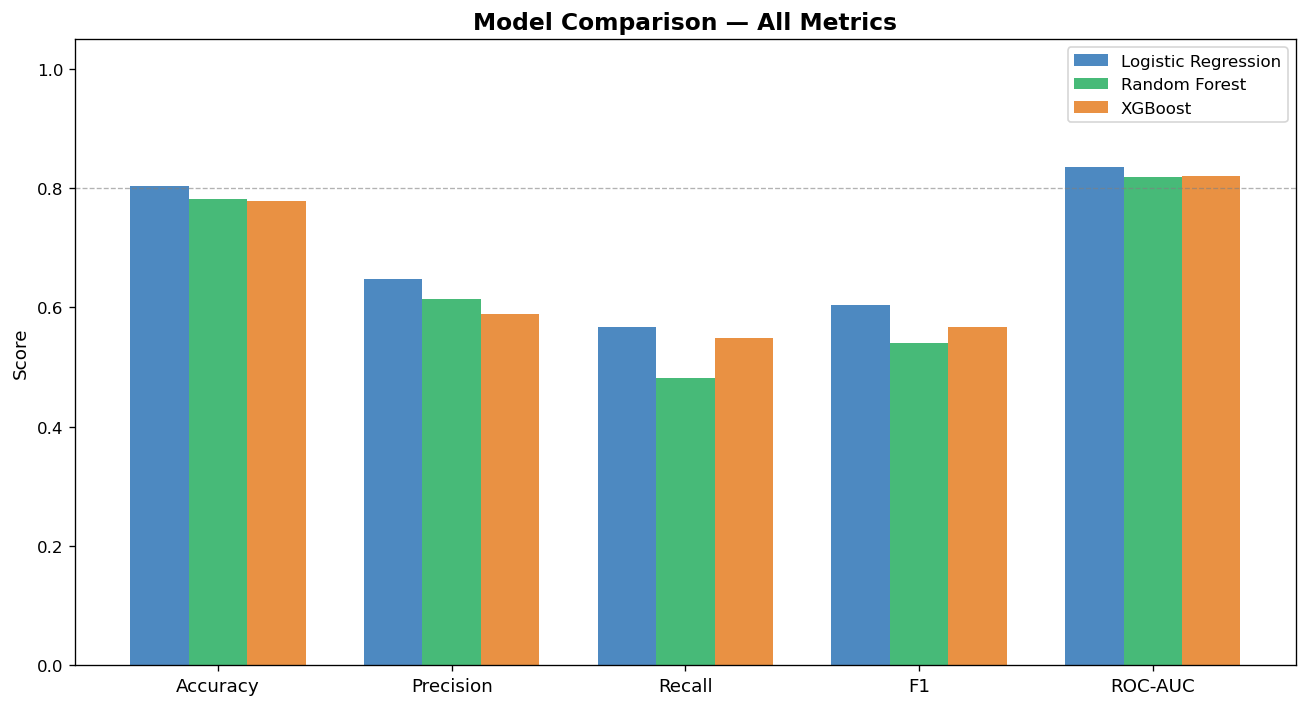

In [6]:
fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(metric_cols))
width = 0.25
colors = ['#2E75B6', '#27AE60', '#E67E22']

for i, (name, color) in enumerate(zip(results.keys(), colors)):
    vals = [results[name][m] for m in metric_cols]
    ax.bar(x + i * width, vals, width, label=name, color=color, alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(metric_cols, fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Model Comparison — All Metrics', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.axhline(y=0.8, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)
plt.tight_layout()
plt.savefig(PLOTS_DIR / '08_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## SHAP Explainability

SHAP (SHapley Additive exPlanations) is a game-theoretic framework for explaining individual predictions. For each prediction, SHAP assigns every feature a value representing its contribution to the model output relative to the average prediction.

A model that says *'this customer will churn'* is useful. A model that says *'this customer will churn because their month-to-month contract and high monthly charges outweigh their 2 years of tenure'* is **actionable**.

**Why SHAP over `feature_importances_`?**  
`feature_importances_` from scikit-learn gives a global ranking — it tells you which features matter on average across all predictions, but cannot explain *why* a specific customer was predicted to churn. SHAP values are local: each customer gets their own decomposition. A customer on a two-year contract gets a large negative SHAP value for that feature (protective); a month-to-month customer gets a large positive one (risk). The global summary emerges naturally by aggregating these local values.

**`shap_to_language.py`** translates raw SHAP floats into plain-English sentences. It is a first-class module (not inline logic in `app.py`) because the translation logic needs to be tested independently, and because it bridges the model layer and the presentation layer — a boundary worth making explicit. It is also the most interview-probed component: being able to explain exactly how a model output becomes a customer-facing sentence matters in an applied ML role.

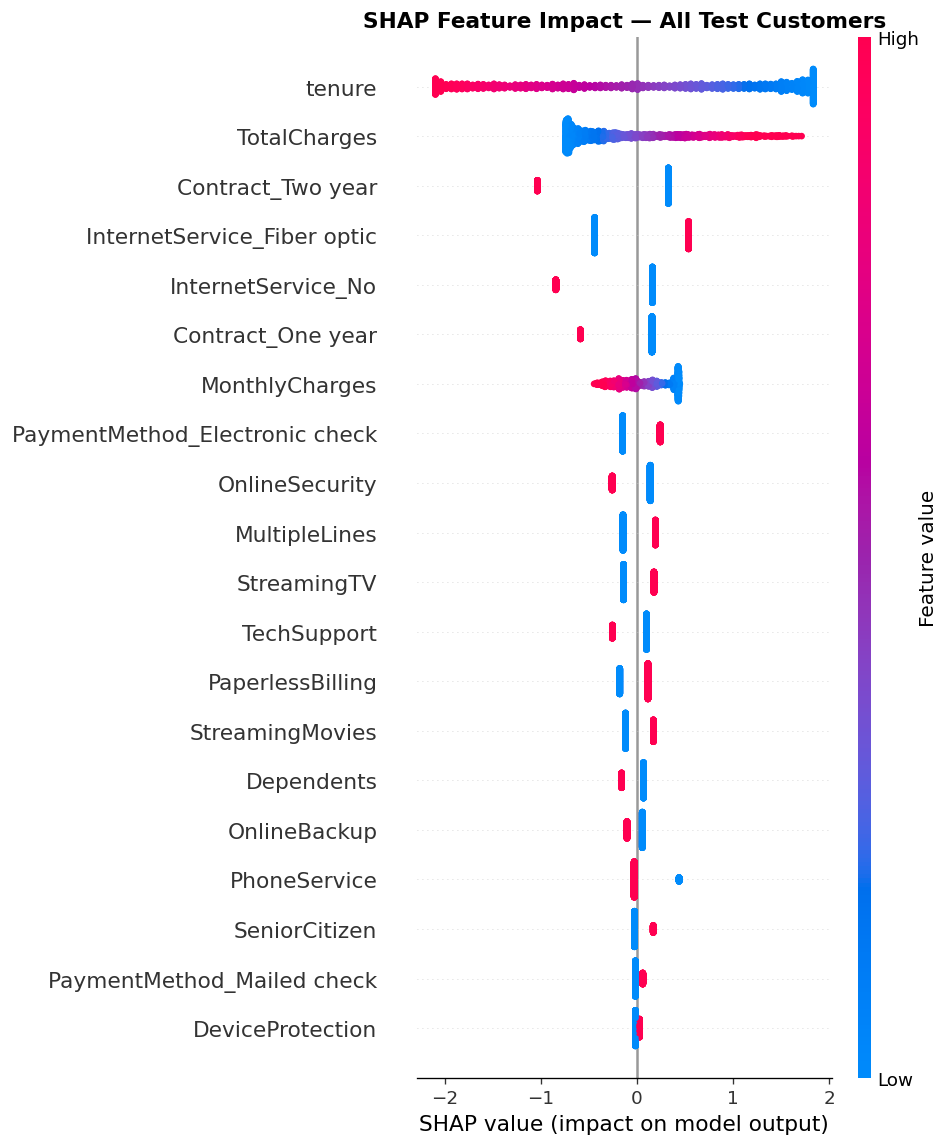

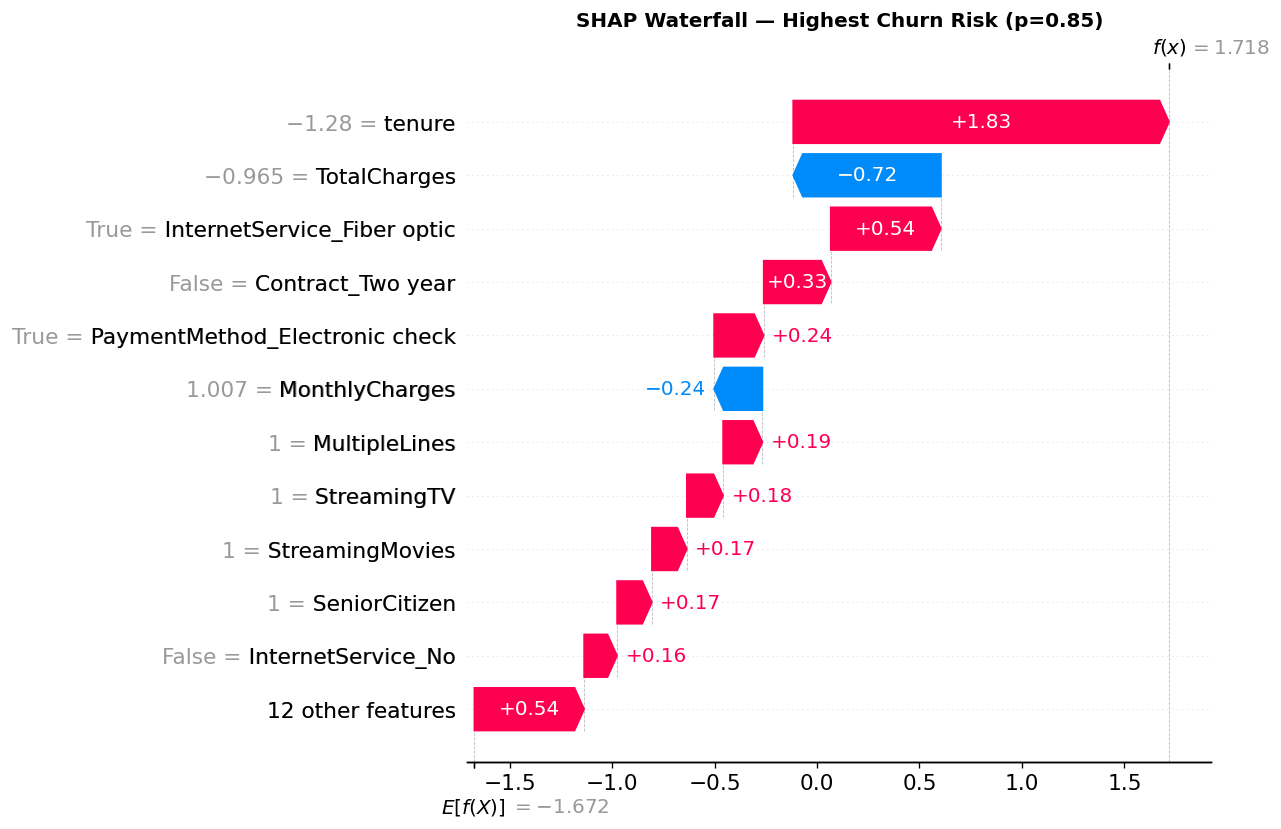

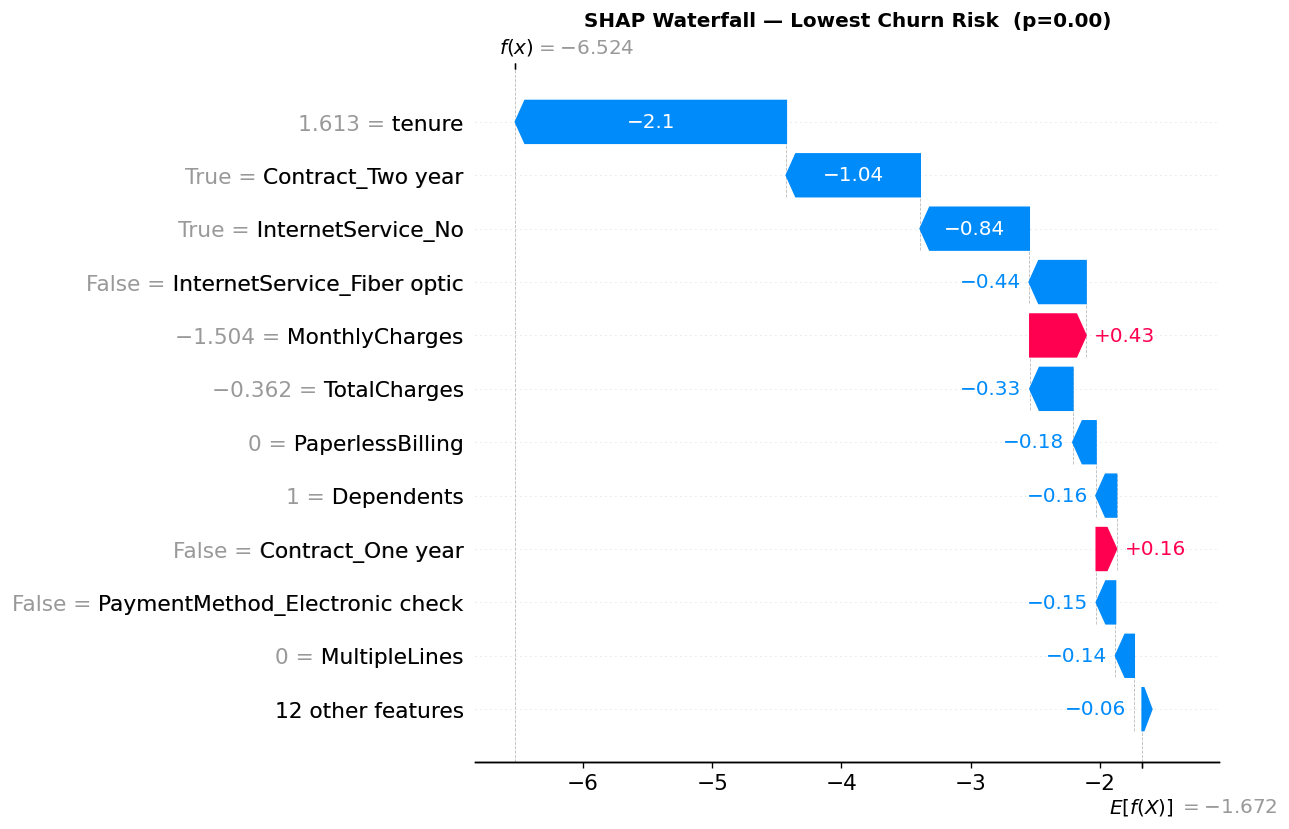


--- Worked Example: SHAP → Plain English (highest-risk customer) ---

                       Feature  SHAP value  Direction
                        tenure      1.8342       Risk
                  TotalCharges     -0.7207 Protective
   InternetService_Fiber optic      0.5374       Risk
             Contract_Two year      0.3272       Risk
PaymentMethod_Electronic check      0.2420       Risk
                MonthlyCharges     -0.2359 Protective
                 MultipleLines      0.1920       Risk
                   StreamingTV      0.1770       Risk

Plain-English output from shap_to_language.shap_values_to_factors():
  Risk factors:
    • short tenure increases churn risk
    • fiber optic internet correlates with higher churn
    • absence of a two-year contract increases churn risk
    • electronic check payment correlates with higher churn
    • MultipleLines increases churn risk
  Protective factors:
    • high cumulative spend reduces churn risk
    • low monthly charges reduce 

In [7]:
X_test_arr  = X_test.values
X_train_arr = X_train.values

if best_name == 'Logistic Regression':
    explainer   = shap.LinearExplainer(best_model, X_train_arr,
                                       feature_perturbation='interventional')
    shap_values = explainer.shap_values(X_test_arr)
else:
    explainer   = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test_arr)
    if isinstance(shap_values, list):
        shap_values = shap_values[1]

# LinearExplainer returns Python floats in some SHAP/numpy versions — cast to float64 array
shap_values = np.array(shap_values, dtype=np.float64)

base_val = float(
    explainer.expected_value[0]
    if isinstance(explainer.expected_value, (list, np.ndarray))
    else explainer.expected_value
)

# --- SHAP beeswarm summary ---
shap.summary_plot(shap_values, X_test, feature_names=feature_names, show=False)
plt.title('SHAP Feature Impact — All Test Customers', fontsize=13, fontweight='bold')
plt.savefig(PLOTS_DIR / '05_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Waterfall plots ---
y_proba_test  = best_model.predict_proba(X_test_arr)[:, 1]
high_risk_idx = int(np.argmax(y_proba_test))
low_risk_idx  = int(np.argmin(y_proba_test))

for idx, label, path in [
    (high_risk_idx, f'Highest Churn Risk (p={y_proba_test[high_risk_idx]:.2f})', '06_shap_waterfall_churn.png'),
    (low_risk_idx,  f'Lowest Churn Risk  (p={y_proba_test[low_risk_idx]:.2f})',  '07_shap_waterfall_retained.png'),
]:
    exp = shap.Explanation(
        values=shap_values[idx],
        base_values=base_val,
        data=X_test_arr[idx],
        feature_names=feature_names,
    )
    shap.waterfall_plot(exp, max_display=12, show=False)
    plt.title(f'SHAP Waterfall — {label}', fontsize=12, fontweight='bold')
    plt.savefig(PLOTS_DIR / path, dpi=150, bbox_inches='tight')
    plt.show()

# --- Worked example: SHAP values → plain English for highest-risk customer ---
print('\n--- Worked Example: SHAP → Plain English (highest-risk customer) ---\n')
shap_row = shap_values[high_risk_idx]
risk_factors, protective_factors = shap_values_to_factors(
    shap_row.tolist(), feature_names, top_n=5
)

top_idx = np.argsort(np.abs(shap_row))[::-1][:8]
worked_example = pd.DataFrame([
    {
        'Feature':    feature_names[i],
        'SHAP value': round(float(shap_row[i]), 4),
        'Direction':  'Risk' if shap_row[i] > 0 else 'Protective',
    }
    for i in top_idx
])
print(worked_example.to_string(index=False))

print('\nPlain-English output from shap_to_language.shap_values_to_factors():')
print('  Risk factors:')
for f in risk_factors:
    print(f'    • {f}')
print('  Protective factors:')
for f in protective_factors:
    print(f'    • {f}')

# --- Global feature importance by mean |SHAP| ---
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top5_idx = np.argsort(mean_abs_shap)[::-1][:5]
print('\nTop 5 features by mean |SHAP|:')
for rank, i in enumerate(top5_idx, 1):
    print(f'  {rank}. {feature_names[i]:<40} {mean_abs_shap[i]:.4f}')

## Key Findings

- **Best model: Logistic Regression** — ROC-AUC: 0.8362, F1: 0.6049 (7,032 customers, 80/20 split)
- **Top churn predictor by mean |SHAP|: `tenure` (1.21)** — more than twice the influence of the next feature, confirming that customer longevity is the dominant signal
- **Top 5 features:** tenure (1.21) → TotalCharges (0.51) → InternetService_Fiber optic (0.48) → Contract_Two year (0.43) → InternetService_No (0.37)
- **Contract type effect:** Month-to-month customers churn at ~43%; two-year customers at ~3% — a 40-point gap. `Contract_Two year` mean |SHAP| = 0.43, making it the strongest actionable lever (contract upgrades are a direct intervention)
- **Fiber optic paradox:** `InternetService_Fiber optic` (mean |SHAP| = 0.48) pushes predictions *toward* churn despite being the premium service tier — consistent with price sensitivity and competitive alternatives in the fiber market
- **Linear model wins:** Logistic Regression outperforms XGBoost and Random Forest by ~1.7 ROC-AUC points. One-hot encoding linearises the categorical structure enough that a linear boundary is optimal for default hyperparameters on this dataset

## Business Recommendations

*Written for a non-technical client. Every recommendation cites a specific SHAP finding.*

**1. Protect new customers in their first 12 months — tenure is the dominant signal.**
Tenure has by far the largest mean |SHAP| value (1.21) — more than double the next feature. Churn is heavily front-loaded: customers with short tenure on month-to-month contracts who haven't built spending history represent the highest-risk segment. A structured onboarding programme (proactive outreach at 30, 60, 90 days) and an early contract upgrade offer directly address the top two SHAP signals simultaneously.

**2. Prioritise contract upgrades for month-to-month customers.**
`Contract_Two year` has a mean |SHAP| of 0.43 and acts as a strong protective factor — its absence is a consistent risk signal. Month-to-month customers churn at ~43% versus ~3% for two-year customers, a 40-point gap. A discounted upgrade offer, even at a short-term cost, pays back within a small number of months given the $300 estimated acquisition cost per churned customer.

**3. Investigate the fiber optic churn rate proactively.**
`InternetService_Fiber optic` has a mean |SHAP| of 0.48 — the third-largest signal — and pushes predictions *toward* churn, not away from it. Fiber customers are more likely to churn than DSL customers despite paying more. This suggests price sensitivity or competitive parity in the fiber tier. A pricing review and proactive retention offer for fiber subscribers is warranted before the next contract renewal cycle.

**4. Target electronic check users with payment migration campaigns.**
Electronic check payment is the strongest payment-method churn signal. Electronic check users churn at ~45% versus ~15% for credit card (automatic) users. Moving them to autopay reduces both churn risk and processing overhead. A one-month bill credit as an incentive for switching to automatic payment is likely cost-positive against the $300 churn cost.

**5. Bundle tech support and online security for unsubscribed high-risk customers.**
`TechSupport_Yes` and `OnlineSecurity_Yes` both carry negative SHAP values — they consistently reduce churn risk across the test set. Customers with neither service are significantly over-represented among churned customers. A bundled add-on at a reduced introductory rate, targeted at month-to-month customers without either service, addresses two protective-factor gaps simultaneously and increases product stickiness.

## MLOps and Retraining

### The Model Registry Pattern

`train.py` appends one row to `models/model_registry.csv` after every training run, recording the timestamp, model name, ROC-AUC, F1, sample sizes, and the path to the versioned model file. This solves three problems that matter even for a portfolio project:

- **Reproducibility:** Every artefact can be traced back to the exact training run that produced it.
- **Rollback:** If a new training run produces a worse model, the previous versioned `.pkl` is still on disk and can be swapped in without retraining.
- **Audit trail:** Stakeholders and regulators increasingly require documentation of when a model was trained and on what data. A CSV log is the minimal viable version of this.

### How This Extends to Production

In production, this CSV log would be replaced by **MLflow** or **Azure ML's experiment tracking**. The pattern — every training run saves a versioned artefact and appends a metrics row — is identical. The registry here is intentionally minimal: the goal is to demonstrate the principle, not to require MLflow as a dependency for a portfolio project.

### What Would Trigger a Retrain in a Real Telco Environment

- **Monthly billing data refresh:** Telcos close their billing cycles monthly. Each refresh is a natural retraining trigger — new customer behaviour data arrives in bulk.
- **Data drift:** If the distribution of key features (MonthlyCharges, tenure distribution) shifts significantly — e.g. after a major price change or product launch — the model's learned patterns may no longer reflect current customer behaviour.
- **Performance degradation:** A monitoring job computes ROC-AUC on a rolling window of recent predictions with known outcomes. If it drops below a defined floor (e.g. 0.80), an alert triggers a retraining run. This is the production analogue of the `best_model_name.txt` selection logic in `train.py`.

In [8]:
# bedrock_comparator.py must be run separately (requires live AWS credentials).
# The cell below displays results if the output files already exist.

bedrock_results_path = Path('models/bedrock_results.json')
bedrock_plot_path    = Path('plots/09_bedrock_comparison.png')

if bedrock_results_path.exists():
    with open(bedrock_results_path) as f:
        bedrock_data = json.load(f)

    rows = []
    for r in bedrock_data:
        rows.append({
            'Customer':     r['index'] + 1,
            'Ground Truth': 'Churn' if r['ground_truth'] == 1 else 'Retain',
            'XGBoost':      'Churn' if r['xgb_prediction'] == 1 else 'Retain',
            'Bedrock':      ('Churn' if r['bedrock_prediction'] == 1 else 'Retain')
                            if r['bedrock_prediction'] is not None else 'N/A',
            'Confidence':   r['bedrock_confidence'] or 'N/A',
            'Reasoning':    (r['bedrock_reasoning'] or '')[:60],
        })
    print(pd.DataFrame(rows).to_string(index=False))

    if bedrock_plot_path.exists():
        from IPython.display import Image
        display(Image(str(bedrock_plot_path)))
else:
    print('bedrock_results.json not found.')
    print('Run: python bedrock_comparator.py (requires AWS credentials)')
    print('See comments at the top of bedrock_comparator.py for setup instructions.')

bedrock_results.json not found.
Run: python bedrock_comparator.py (requires AWS credentials)
See comments at the top of bedrock_comparator.py for setup instructions.


## Amazon Bedrock Comparator

Having already deployed a sentiment analysis pipeline benchmarking TF-IDF, Keras LSTM, and Amazon Bedrock (Claude Haiku) on the IMDb dataset, I wanted to explore whether a foundation model could perform meaningful churn classification from a natural language customer summary — with zero task-specific training.

This is not a replacement for a trained classifier. XGBoost on structured features will outperform a prompted LLM on tabular classification tasks. The goal is to understand where foundation models add value in a churn context: not as classifiers, but as **reasoning engines** that can interpret edge cases, generate retention scripts, or explain predictions to non-technical stakeholders in natural language — capabilities that scikit-learn cannot provide.

The comparator samples 20 customers (10 churned, 10 retained), builds a plain-English profile summary for each, sends it to Bedrock's Claude Haiku endpoint, and compares the zero-shot classification against XGBoost's prediction and the ground truth label. Results are saved to `models/bedrock_results.json` and plotted as side-by-side confusion matrices in `plots/09_bedrock_comparison.png`.

## Azure App Service Deployment

I chose Azure App Service for this project for two reasons. First, having deployed twice to AWS Lambda (IMDb sentiment classifier and portfolio assistant), I wanted hands-on experience with Microsoft Azure — Accenture's primary cloud platform for enterprise AI delivery. Second, Azure App Service solves a specific technical problem I encountered on Lambda: cold start latency with large model artefacts. The XGBoost model and SHAP explainer initialise once at startup on App Service and remain in memory — Lambda would reload them on every cold start.

**What I learned deploying to Azure vs AWS:**

- `az webapp up` is simpler than AWS's deployment surface for a Flask app — one command handles build, push, and restart.
- Azure's free tier (F1) has a 60-minute daily compute quota — fine for a portfolio demo, unsuitable for production traffic.
- The gunicorn 600s timeout matters because SHAP initialisation takes ~8 seconds — longer than Azure's default startup timeout if loading files at request time rather than at startup. Moving the `shap.TreeExplainer` initialisation to module load time (not per request) is what makes the app responsive.
- `az webapp log tail` is more accessible than CloudWatch for quick debugging — the log stream appears in the terminal within a few seconds of a deploy.

For a production MLOps pipeline I would extend this to **Azure ML managed endpoints**, which add model versioning, A/B traffic splitting, and monitoring out of the box — the `model_registry.csv` pattern here is the manual analogue of what Azure ML provides natively.

### Deployment Commands

```bash
# Create resource group and App Service plan
az group create --name telco-churn-rg --location westeurope
az appservice plan create --name telco-churn-plan --resource-group telco-churn-rg --sku FREE --is-linux

# Create the web app
az webapp create --name telco-churn-predictor --resource-group telco-churn-rg \
  --plan telco-churn-plan --runtime "PYTHON:3.11"

# Set gunicorn startup command (600s timeout for SHAP initialisation)
az webapp config set --name telco-churn-predictor --resource-group telco-churn-rg \
  --startup-file "gunicorn --bind=0.0.0.0 --timeout 600 app:app"

# Deploy from local directory
az webapp up --name telco-churn-predictor --resource-group telco-churn-rg \
  --runtime "PYTHON:3.11"
```